<a href="https://colab.research.google.com/github/naoya1110/ai_robotics_lab_2026_hands_on/blob/main/Week02_Simple_Gradient_Descent_Example__with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Gradient Descent Example with PyTorch

A neural network has many **weights** and **biases**. Training means finding good values for them. In this notebook, we will learn how to find these values with a method called **gradient descent**.

We will use a very simple model, a straight line (linear regression), and build it with PyTorch.

First, let's import PyTorch, NumPy and Matplotlib.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Here, we make a dataset of inputs $x$ and outputs $y$ with the simple equation below. Please note that $y$ has some random **noise**, so the points are not exactly on a straight line.

$y = 5x + 3 + \mathrm{noise}$

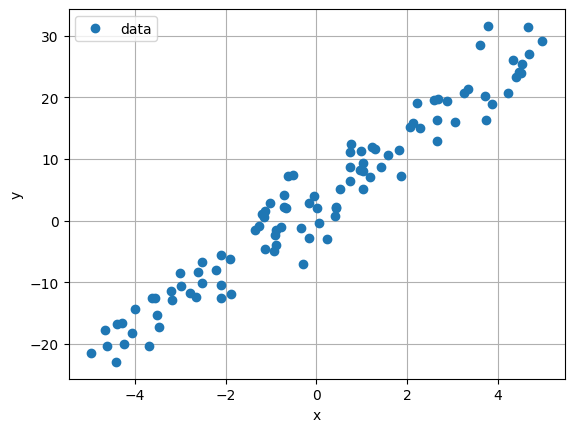

In [2]:
x = 10*np.random.rand(100)-5
noise = 3*np.random.randn(x.shape[0])
y = 5*x + 3 + noise

plt.plot(x, y, marker="o", lw= 0, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

## Least Squares Polynomial Fit

Our goal is to find a straight line (an equation) that fits the $x$ and $y$ data well.

Actually, we can do this without PyTorch. NumPy has the function `np.polyfit()`, which finds the best line $y = wx + b$ for the data. Here $w$ is called the **weight** and $b$ is called the **bias**.

In [3]:
w, b = np.polyfit(x, y, 1)
print(f"w={w:.3f}, b={b:.3f}")

w=5.055, b=3.277


Because the data has noise, $w$ and $b$ are not exactly 5 and 3. But they are close enough, so we can draw a good line with them.

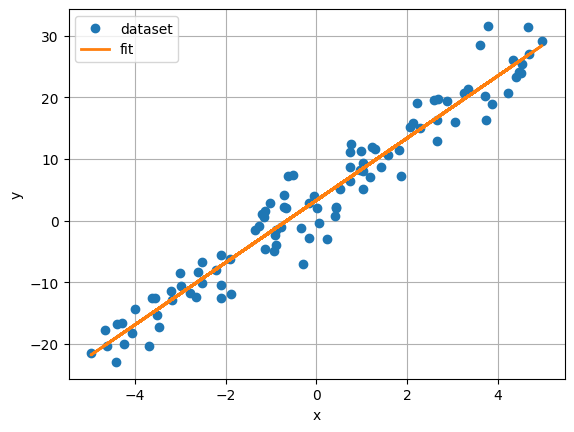

In [4]:
y_fit = w*x + b

plt.plot(x, y, marker="o", lw=0, label="dataset")
plt.plot(x, y_fit, lw=2, label="fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

## Gradient Descent

`np.polyfit()` works well. But now, let's get the same result with PyTorch, in the same way that neural networks are trained.

First, we change the $x$ and $y$ data into tensors (`torch.tensor`).

In [5]:
x = torch.tensor(x)
y = torch.tensor(y)

print(type(x))
print(type(y))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


Next, we make a function `model()`. It takes an input `x` and returns a prediction `p`, using the parameters `w` and `b`.

In [6]:
def model(x):
    p = w*x + b
    return p

We also make a function `loss_func()`. It calculates the **mean squared error (MSE)** between the prediction `p` and the correct answer `y`: we take the difference for each data point, square it, and take the average.

This kind of function is called a **loss function**. It shows how wrong the model's predictions are. A smaller loss means a better model.

$\displaystyle \mathrm{loss} = \mathrm{mse}(p, y) = \frac{1}{N}\sum_{i=0}^{N-1}(p_i-y_i)^2$

In [7]:
def loss_func(p, y):
    loss = ((p-y)**2).mean()
    return loss

We do not know good values of `w` and `b` yet. So we start with any numbers we like. We also set `requires_grad=True`, because we need their gradients later.

In [8]:
w = torch.tensor(-1.0, requires_grad=True)   # you can set any number here
b = torch.tensor(-10.0, requires_grad=True)  # you can set any number here

Now we can make a prediction with `model()`.

In [9]:
p = model(x)
print(p)

tensor([-14.6544,  -6.0113,  -6.7960, -10.7539,  -9.9541,  -7.7857,  -7.0100,
         -7.2126, -14.9713, -10.4389, -12.2249, -12.6619, -10.5209, -13.3478,
         -7.8905, -11.4279, -10.4387,  -7.3924,  -9.8376,  -7.9062,  -9.2773,
        -11.0381, -14.6767,  -6.8159,  -7.4905,  -6.3056, -13.8693, -13.7788,
         -7.4876,  -9.2261, -10.0495, -10.7495, -12.2867,  -8.6553, -13.0656,
         -9.3833, -11.2977, -11.5795, -13.7182,  -9.1045,  -6.3694,  -7.9072,
        -12.8808,  -6.4372, -11.2299, -11.0320, -14.4618,  -9.0897, -14.4000,
        -11.1905, -13.2459,  -8.8558, -10.2264,  -7.0059,  -8.1106,  -8.0911,
        -12.1332,  -9.8382,  -9.1196, -11.8194,  -5.5859,  -5.7100,  -9.6583,
        -11.8664, -14.2145, -10.9632,  -8.7293, -12.0617, -14.3356, -10.0062,
         -5.6154,  -9.0593, -12.6596,  -8.8586,  -6.4876, -13.6129,  -5.0370,
        -13.7386, -12.5910,  -5.9352,  -8.9705, -12.6737, -11.0223,  -9.3215,
        -10.7458,  -5.3875,  -5.7546,  -8.8776, -10.9941, -10.40

Let's draw the prediction. We chose `w` and `b` freely, so the line does not fit the data yet.

Text(0, 0.5, 'y')

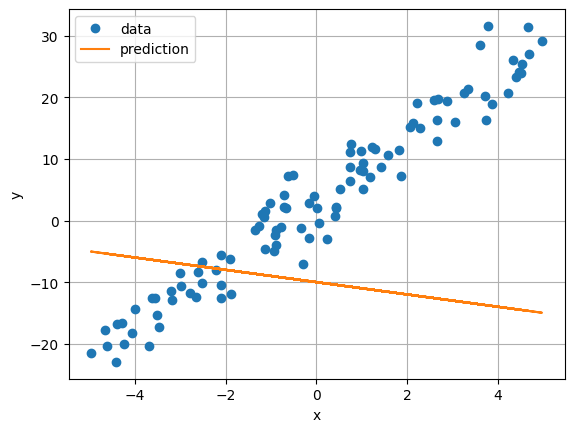

In [10]:
plt.plot(x, y, marker="o", lw=0, label="data")
plt.plot(x, p.detach().numpy(), label="prediction")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

Next, we calculate the loss (the mean squared error) with `loss_func()`. The loss is very large, because `w` and `b` are not good values yet.

In [11]:
loss = loss_func(p, y)
print(loss)

tensor(449.9863, dtype=torch.float64, grad_fn=<MeanBackward0>)


To improve `w` and `b`, we need to know which way to change them. The **gradients** tell us this. A gradient shows how much the loss changes when we change `w` (or `b`) a little.

Call `loss.backward()` to calculate the gradients. Then you can see $\displaystyle \frac{\partial \mathrm{loss}}{\partial w}$ in `w.grad` and $\displaystyle \frac{\partial \mathrm{loss}}{\partial b}$ in `b.grad`.

In [12]:
loss.backward()
print(w.grad)
print(b.grad)

tensor(-86.9480)
tensor(-26.5139)


Now we update `w` and `b` with the equations below. $\eta$ (eta) is the **learning rate**. It decides how big each step is.

$\displaystyle w \leftarrow w - \eta\frac{\partial\mathrm{loss}}{\partial w}$

$\displaystyle b \leftarrow b - \eta\frac{\partial\mathrm{loss}}{\partial b}$

The gradient points in the direction where the loss gets **bigger**. So we move `w` and `b` in the **opposite** direction (this is why we use minus). This method is called **gradient descent**.

Note: In this notebook, we use all the data at every step. In real deep learning, the dataset is very large, so we often use only a small part of the data (a **mini-batch**) at each step. This version is called **stochastic gradient descent (SGD)**, and you will see it again in PyTorch as `torch.optim.SGD`.

We do not want PyTorch to calculate gradients for this update step itself. So we write the update inside `with torch.no_grad():`.

In [13]:
lr = 0.01    # define learning rate

with torch.no_grad():    # disable gradients calculations
    w -= w.grad*lr       # update w
    b -= b.grad*lr       # update b

Look at the new values. `w` and `b` are a little closer to the true values ($w$ = 5.0, $b$ = 3.0) than the starting values.

In [14]:
print(w)
print(b)

tensor(-0.1305, requires_grad=True)
tensor(-9.7349, requires_grad=True)


Text(0, 0.5, 'y')

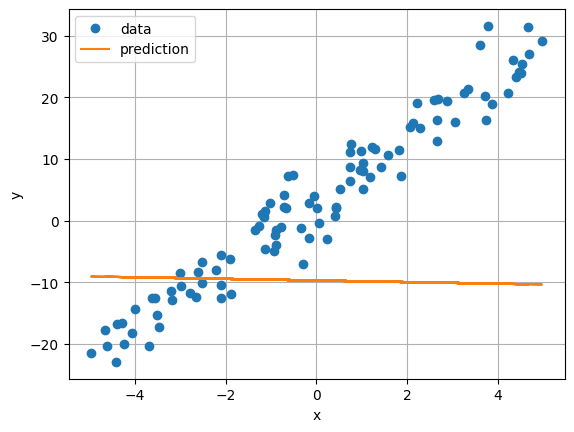

In [15]:
with torch.no_grad():
    p = model(x)

plt.plot(x, y, marker="o", lw=0, label="data")
plt.plot(x, p.detach().numpy(), label="prediction")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

One update is not enough. So we repeat the same steps many times: **predict -> calculate the loss -> calculate the gradients -> update `w` and `b`**. One repeat is called an **epoch**.

Please note `w.grad.zero_()` and `b.grad.zero_()`. PyTorch *adds* new gradients to the old ones, so we must reset the gradients to 0 after each update.

In [16]:
w = torch.tensor(-1.0, requires_grad=True)   # you can set any number here
b = torch.tensor(-10.0, requires_grad=True)  # you can set any number here

lr = 0.01    # learning rate
epochs = 100  # how many times we repeat training

# empty lists for saving loss, w, b
loss_list = []
w_list = []
b_list = []

for epoch in range(epochs):

    p = model(x)              # prediction
    loss = loss_func(p, y)    # measure loss
    loss.backward()           # determine gradients

    with torch.no_grad():     # disable autograd
        w -= w.grad*lr        # update w
        b -= b.grad*lr        # update b

        w.grad.zero_() # reset gradient
        b.grad.zero_() # reset gradient

    # save loss, w, b
    loss_list.append(loss.item())
    w_list.append(w.item())
    b_list.append(b.item())

    print(f"Epoch {epoch+1}, loss={loss.item():.3f}, w={w.item():.3f}, b={b.item():.3f}")

Epoch 1, loss=449.986, w=-0.131, b=-9.735
Epoch 2, loss=372.859, w=0.614, b=-9.475
Epoch 3, loss=314.723, w=1.252, b=-9.220
Epoch 4, loss=270.574, w=1.797, b=-8.971
Epoch 5, loss=236.740, w=2.265, b=-8.726
Epoch 6, loss=210.528, w=2.665, b=-8.486
Epoch 7, loss=189.960, w=3.008, b=-8.251
Epoch 8, loss=173.582, w=3.301, b=-8.020
Epoch 9, loss=160.329, w=3.553, b=-7.795
Epoch 10, loss=149.416, w=3.768, b=-7.573
Epoch 11, loss=140.266, w=3.952, b=-7.356
Epoch 12, loss=132.455, w=4.110, b=-7.144
Epoch 13, loss=125.668, w=4.245, b=-6.935
Epoch 14, loss=119.674, w=4.361, b=-6.731
Epoch 15, loss=114.303, w=4.460, b=-6.531
Epoch 16, loss=109.426, w=4.545, b=-6.335
Epoch 17, loss=104.949, w=4.618, b=-6.143
Epoch 18, loss=100.800, w=4.680, b=-5.954
Epoch 19, loss=96.928, w=4.733, b=-5.770
Epoch 20, loss=93.290, w=4.779, b=-5.589
Epoch 21, loss=89.856, w=4.818, b=-5.411
Epoch 22, loss=86.601, w=4.852, b=-5.238
Epoch 23, loss=83.508, w=4.880, b=-5.067
Epoch 24, loss=80.561, w=4.905, b=-4.901
Epoch 

Look at the last lines of the output. `w` is now very close to 5.0. `b` is still moving toward 3.0, but it has not reached 3.0 yet after 100 epochs. The loss is also still going down. If we train for more epochs, `b` will come closer to 3.0.

Let's draw how the loss went down.

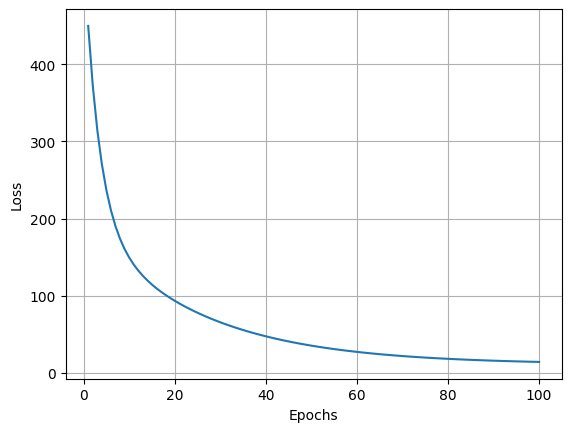

In [17]:
plt.plot(np.arange(epochs)+1, loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()

Let's draw how `w` changed.

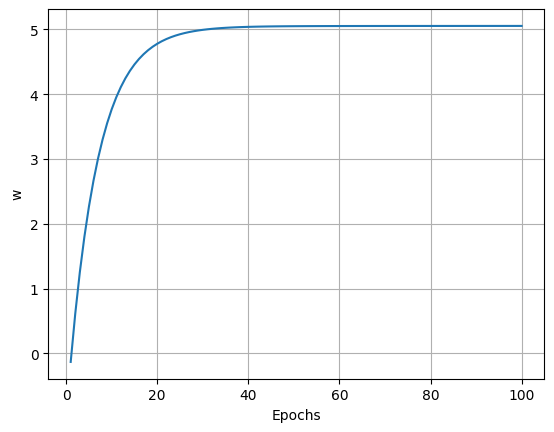

In [18]:
plt.plot(np.arange(epochs)+1, w_list)
plt.xlabel("Epochs")
plt.ylabel("w")
plt.grid()

Let's draw how `b` changed.

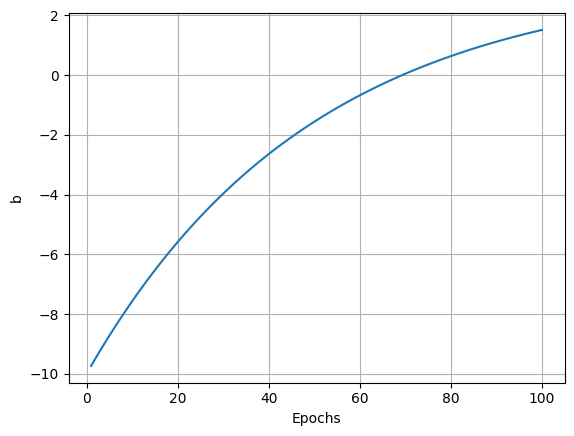

In [19]:
plt.plot(np.arange(epochs)+1, b_list)
plt.xlabel("Epochs")
plt.ylabel("b")
plt.grid()

With the trained values of `w` and `b`, the prediction line now fits the data much better than at the start.

Text(0, 0.5, 'y')

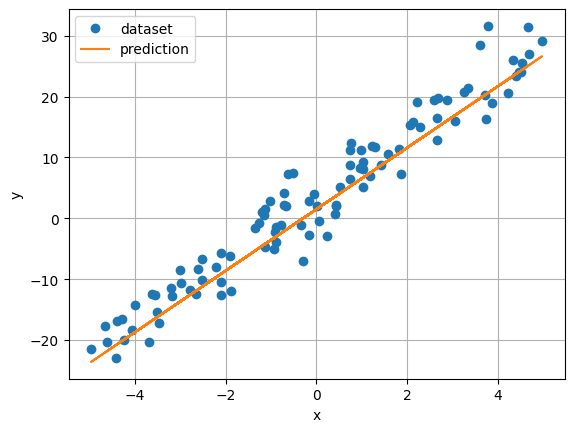

In [20]:
plt.plot(x, y, marker="o", lw=0, label="dataset")
plt.plot(x, p.detach().numpy(), label="prediction")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("y")

Now it is your turn. Try changing the values of `epochs`, `lr`, and the starting values of `w` and `b`. Then look at how the results change. For example, can you make `b` closer to 3.0?